In [2]:
from core import AnalysisConfig, Reference, ObsType
from utils import Analyzer, ResultsManager
from utils.workdirectory import WorkDirectory

In [3]:
%config InlineBackend.figure_format = 'retina'

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep
import matplotlib.cm as cm
from pathlib import Path

mplhep.style.use("CMS")

def _cms_setup(figsize, label_fs=26, tick_fs=26, cms_fs=26):
    """Common CMS plot setup"""
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color('black')
    
    ax.tick_params(axis='y', which='major', direction='in', length=6, width=2,
                   labelsize=tick_fs, top=True, right=True, bottom=True, left=True, color='black')
    ax.tick_params(axis='y', which='minor', direction='in', length=3, width=1,
                   top=True, right=True, bottom=True, left=True, color='black')
    
    ax.grid(True, alpha=0.3, axis='y', linestyle='-', linewidth=0.8, color='#cccccc')
    ax.grid(False, axis='x')
    
    return fig, ax, label_fs, tick_fs, cms_fs

def _cms_text(ax, cms_fs):
    """Add CMS text"""
    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fs, loc=0)
    ax.text(1.0, 1.0, "13.6 TeV", transform=ax.transAxes, fontsize=cms_fs,
            horizontalalignment='right', verticalalignment='bottom')

def scatterplot_UL_by_type(df: pd.DataFrame, outfile):
    fig, ax, label_fs, tick_fs, cms_fs = _cms_setup((20, 12))
    
    x_positions, y_values, colors, labels, categories = [], [], [], [], []
    current_x = 1
    
    type_mapping = {
        'llr_from_1D': ('Univariate LLR', '#e74c3c', '#c0392b'),
        'llr_from_2D': ('Bivariate LLR', '#3498db', '#2980b9'), 
        'llr_from_3D': ('Trivariate LLR', '#2ecc71', '#27ae60')
    }
    region_colors = ['#ffeaea', '#eaf4ff', '#eafff0']
    region_boundaries = []
    
    for region_index, (obs_type, (label, color_main, color_dark)) in enumerate(type_mapping.items()):
        subset = df[df['obs_type'] == obs_type]
        if not subset.empty:
            ax.axvspan(current_x - 0.5, current_x + 0.5, facecolor=region_colors[region_index], alpha=0.3, zorder=0)
            if current_x > 1: region_boundaries.append(current_x - 0.5)
            
            x_jitter = np.random.normal(current_x, 0.08, len(subset))
            ax.scatter(x_jitter, subset['mu'], c=color_main, s=120, alpha=0.3, edgecolors='none', zorder=1)
            ax.scatter(x_jitter, subset['mu'], c=subset['mu'], cmap='viridis', s=80, alpha=0.8, edgecolors=color_dark, linewidth=1.2, zorder=3)
            
            x_positions.extend(x_jitter)
            y_values.extend(subset['mu'].tolist())
            colors.extend([color_main] * len(subset))
            labels.append(label)
            categories.extend([label] * len(subset))
            current_x += 1
    
    # Multivariate section
    multivar_df = df[df['obs_type'] == 'llr_factorized']
    if not multivar_df.empty:
        n_var_values = sorted(multivar_df['n_variables'].unique())
        plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(n_var_values)))
        multivar_names = {i: str(i) for i in range(2, 17)}
        multivar_region_colors = plt.cm.plasma(np.linspace(0.05, 0.15, len(n_var_values)))
        
        for i, n_vars in enumerate(n_var_values):
            x_center = current_x + i
            ax.axvspan(x_center - 0.5, x_center + 0.5, facecolor=multivar_region_colors[i], alpha=0.2, zorder=0)
            if i > 0: region_boundaries.append(x_center - 0.5)
            elif current_x > 1: region_boundaries.append(x_center - 0.5)
        
        for i, n_vars in enumerate(n_var_values):
            subset = multivar_df[multivar_df['n_variables'] == n_vars]
            x_center = current_x + i
            x_jitter = np.random.normal(x_center, 0.06, len(subset))
            
            ax.scatter(x_jitter, subset['mu'], c=plasma_colors[i], s=120, alpha=0.3, edgecolors='none', zorder=1)
            ax.scatter(x_jitter, subset['mu'], c=subset['mu'], cmap='viridis', s=80, alpha=0.8, edgecolors=plasma_colors[i], linewidth=1.2, zorder=3)
            
            x_positions.extend(x_jitter)
            y_values.extend(subset['mu'].tolist())
            colors.extend([plasma_colors[i]] * len(subset))
            labels.append(multivar_names.get(n_vars, f"Multi-{n_vars}"))
            categories.extend([f"{n_vars}"] * len(subset))
    
    if not y_values:
        print("No data to plot!")
        return
    
    for boundary_x in region_boundaries:
        ax.axvline(boundary_x, color='#cccccc', alpha=0.6, linestyle='-', linewidth=1.5, zorder=2)
    
    ax.tick_params(axis='x', which='major', direction='in', length=0, width=0, labelsize=tick_fs, top=False, right=False, bottom=True, left=False, color='black')
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=tick_fs)
    ax.set_ylabel('Median UL on μ', fontsize=label_fs)
    ax.set_xlabel('Number of Variables in LLR', fontsize=label_fs)
    
    _cms_text(ax, cms_fs)
    plt.tight_layout()
    
    ax.set_xlim(0.5, len(labels) + 0.5)
    y_range = max(y_values) - min(y_values) 
    y_min, y_max = 150, max(y_values) + 0.08 * y_range
    ax.set_ylim(y_min, y_max)
    
    tick_list = [200] + list(np.arange(200, 4300, 400)[np.arange(200, 4300, 400) <= y_max])
    ax.set_yticks(sorted(list(set(tick_list))))
    
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style enhanced scatter plot saved to {outfile}")
    plt.show()

def hierarchical_UL_plot(ranked_df: pd.DataFrame, outfile, ylabel):
    fig, ax, label_fs, tick_fs, cms_fs = _cms_setup((14, max(8, len(ranked_df) * 0.35 + 2)), 24, 20, 20)
    
    norm = plt.Normalize(vmin=ranked_df['mu'].min(), vmax=ranked_df['mu'].max())
    colors = cm.viridis(norm(ranked_df['mu']))
    y_positions = np.arange(len(ranked_df))
    
    ax.barh(y_positions, ranked_df['mu'], color=colors, alpha=0.2, edgecolor='none', height=0.9)
    bars = ax.barh(y_positions, ranked_df['mu'], color=colors, alpha=0.85, edgecolor='white', linewidth=1.5, height=0.7)
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(ranked_df['obs_name'], fontsize=tick_fs)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=2, labelsize=tick_fs, top=True, right=True, bottom=True, left=True, color='black')
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=1, top=True, right=True, bottom=True, left=True, color='black')
    ax.tick_params(axis='y', which='both', length=0)
    
    ax.set_ylim(-0.5, len(ranked_df) - 0.5)
    max_value = max(ranked_df['mu'])
    ax.set_xlim(0, max_value * 1.12)
    ax.set_xlabel('Median UL on μ', fontsize=label_fs)
    ax.set_ylabel(ylabel, fontsize=label_fs)
    
    ax.grid(True, alpha=0.3, axis='x', linestyle='-', linewidth=0.8, color='#cccccc')
    ax.grid(False, axis='y')
    ax.set_axisbelow(True)
    
    for i, (bar, value) in enumerate(zip(bars, ranked_df['mu'])):
        ax.text(value + max_value * 0.015, i, f'{value:.0f}', va='center', ha='left', fontsize=tick_fs-2,
               color='#2c3e50', weight='normal', bbox=dict(boxstyle='round,pad=0.25', facecolor='white', 
               edgecolor='#cccccc', linewidth=0.5, alpha=0.9))
    
    _cms_text(ax, cms_fs)
    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=False))
    
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style hierarchical plot saved to {outfile}")
    plt.show()

def plot_llr_factorized_trend(df: pd.DataFrame, outfile: Path):
    mdf = df[df["obs_type"] == "llr_factorized"].copy()
    if "n_variables" not in mdf.columns:
        raise ValueError("llr_factorized rows must include n_variables")
    
    g = mdf.groupby("n_variables")["mu"]
    order = sorted(g.groups.keys())
    med, q25, q75, q10, q90 = [g.quantile(q).reindex(order) for q in [0.5, 0.25, 0.75, 0.1, 0.9]]
    
    fig, ax = plt.subplots(figsize=(9,6))
    ax.plot(order, med.values, marker="o", lw=2, label="Median")
    ax.fill_between(order, q25.values, q75.values, alpha=0.25, label="IQR (25–75%)")
    ax.fill_between(order, q10.values, q90.values, alpha=0.15, label="10–90%")
    ax.set_xlabel("Number of observables in factorized LLR")
    ax.set_ylabel(r"Expected 95% CL UL on $\mu$")
    ax.grid(True, alpha=0.4)
    ax.legend(frameon=False)
    
    fig.tight_layout()
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved to {outfile}")

def boxplot_UL_by_type(df: pd.DataFrame, outfile):
    fig, ax, label_fs, tick_fs, cms_fs = _cms_setup((20, 12))
    
    type_mapping = {
        'llr_from_1D': ('Uni.', '#e74c3c', '#c0392b'),
        'llr_from_2D': ('Bi.', '#3498db', '#2980b9'), 
        'llr_from_3D': ('Tri.', '#2ecc71', '#27ae60')
    }
    
    box_data, box_labels, box_colors, box_edge_colors, box_positions = [], [], [], [], []
    current_pos = 1
    region_colors = ['#ffeaea', '#eaf4ff', '#eafff0']
    region_boundaries = []
    
    for region_index, (obs_type, (label, color_main, color_dark)) in enumerate(type_mapping.items()):
        subset = df[df['obs_type'] == obs_type].dropna(subset=['mu'])
        if not subset.empty:
            ax.axvspan(current_pos - 0.5, current_pos + 0.5, facecolor=region_colors[region_index], alpha=0.3, zorder=0)
            if current_pos > 1: region_boundaries.append(current_pos - 0.5)
            
            box_data.append(subset['mu'].values)
            box_labels.append(label)
            box_colors.append(color_main)
            box_edge_colors.append(color_dark)
            box_positions.append(current_pos)
            current_pos += 1
    
    multivar_df = df[df['obs_type'] == 'llr_factorized']
    if not multivar_df.empty:
        n_var_values = sorted(multivar_df['n_variables'].unique())
        plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(n_var_values)))
        plasma_dark_colors = plt.cm.plasma(np.linspace(0.3, 1.0, len(n_var_values)))
        multivar_region_colors = plt.cm.plasma(np.linspace(0.05, 0.15, len(n_var_values)))
        multivar_names = {i: str(i) for i in range(2, 17)}
        
        for i, n_vars in enumerate(n_var_values):
            x_center = current_pos + i
            ax.axvspan(x_center - 0.5, x_center + 0.5, facecolor=multivar_region_colors[i], alpha=0.2, zorder=0)
            if i > 0: region_boundaries.append(x_center - 0.5)
            elif current_pos > 1: region_boundaries.append(x_center - 0.5)
            
            subset = multivar_df[multivar_df['n_variables'] == n_vars].dropna(subset=['mu'])
            if not subset.empty:
                box_data.append(subset['mu'].values)
                box_labels.append(multivar_names.get(n_vars, f"Multi-{n_vars}"))
                box_colors.append(plasma_colors[i])
                box_edge_colors.append(plasma_dark_colors[i])
                box_positions.append(x_center)
    
    if not box_data:
        print("No data to plot!")
        return
    
    bp = ax.boxplot(box_data, positions=box_positions, patch_artist=True, widths=0.7, whis=[10, 90], showfliers=True,
                    boxprops=dict(linewidth=2.5), whiskerprops=dict(linewidth=2.5, linestyle='-'),
                    capprops=dict(linewidth=2.5), medianprops=dict(linewidth=3.5, color='white'),
                    flierprops=dict(marker='o', markersize=7, alpha=0.8))
    
    # Style boxes with shadows and gradients
    for i, (patch, color, edge_color) in enumerate(zip(bp['boxes'], box_colors, box_edge_colors)):
        shadow_height = np.percentile(box_data[i], 75) - np.percentile(box_data[i], 25)
        shadow_bottom = np.percentile(box_data[i], 25)
        shadow = plt.Rectangle((box_positions[i] - 0.35 + 0.02, shadow_bottom - 0.02), 0.7, shadow_height, facecolor='gray', alpha=0.2, zorder=1)
        ax.add_patch(shadow)
        
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        patch.set_edgecolor(edge_color)
        patch.set_linewidth(2.5)
        
        inner_box = plt.Rectangle((box_positions[i] - 0.25, np.percentile(box_data[i], 60)), 0.5, 
                                 np.percentile(box_data[i], 75) - np.percentile(box_data[i], 60),
                                 facecolor='white', alpha=0.15, zorder=3)
        ax.add_patch(inner_box)
    
    for i, whisker in enumerate(bp['whiskers']):
        whisker.set_color(box_edge_colors[i // 2])
        whisker.set_linewidth(2.5)
        whisker.set_alpha(0.8)
    
    for i, cap in enumerate(bp['caps']):
        cap.set_color(box_edge_colors[i // 2])
        cap.set_linewidth(2.5)
        cap.set_alpha(0.8)
    
    for i, median in enumerate(bp['medians']):
        ax.plot(median.get_xdata(), median.get_ydata(), color='black', linewidth=5, alpha=0.3, zorder=3)
    
    for flier, box_idx in zip(bp['fliers'], range(len(box_data))):
        if len(flier.get_data()[1]) > 0:
            flier.set_markerfacecolor(box_colors[box_idx])
            flier.set_markeredgecolor(box_edge_colors[box_idx])
            flier.set_markersize(8)
            flier.set_alpha(0.8)
            flier.set_markeredgewidth(1.5)
    
    for boundary_x in region_boundaries:
        ax.axvline(boundary_x, color='#cccccc', alpha=0.6, linestyle='-', linewidth=1.5, zorder=2)
    
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', which='major', direction='in', length=0, width=0, labelsize=tick_fs, top=False, right=False, bottom=True, left=False, color='black')
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    
    ax.set_xticks(box_positions)
    ax.set_xticklabels(box_labels, fontsize=tick_fs)
    ax.set_ylabel('Median UL on μ', fontsize=label_fs)
    ax.set_xlabel('Number of Variables in LLR', fontsize=label_fs)
    
    ax.set_xlim(0.5, len(box_labels) + 0.5)
    all_values = np.concatenate(box_data)
    y_range = max(all_values) - min(all_values)
    y_min, y_max = 150, max(all_values) + 0.08 * y_range
    ax.set_ylim(y_min, y_max)
    
    tick_list = [200] + list(np.arange(200, 4300, 400)[np.arange(200, 4300, 400) <= y_max])
    ax.set_yticks(sorted(list(set(tick_list))))
    
    _cms_text(ax, cms_fs)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style enhanced boxplot saved to {outfile}")
    plt.show()

In [25]:
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/')
if True:
    # Run over crtd_final
    subprojectdir = projectdir / 'crtd_final'
    crtd_dirs = [d for d in subprojectdir.iterdir() if d.is_dir() and 'LLR_cmb' in d.name]

    avail_dirs, unavail_dirs = [], []
    for wd in crtd_dirs:
        sum_results = wd / 'fits_new' / 'summary_results.txt'
        if sum_results.exists():    avail_dirs.append(wd)
        else:   unavail_dirs.append(wd)

    print(f"Available directories: {len(avail_dirs)} out of {len(crtd_dirs)}")
    for wd in avail_dirs: print(f"\t{wd.name}")

    file_paths = [wd / 'fits_new' / 'summary_results.txt' for wd in avail_dirs]
    df_llrs_fact = ResultsManager.load_summary_files(file_paths)
else:
    # Run over outdated crtd
    subprojectdir = projectdir / 'crtd'
    crtd_dirs = [d for d in subprojectdir.iterdir() if d.is_dir() and '_crtd_odd_' in d.name]
    file_paths = [wd / 'fits_new' / 'summary_results.txt' for wd in crtd_dirs]
    df_llrs_fact = ResultsManager.load_summary_files(file_paths)
df_llrs_fact

Available directories: 13 out of 28
	LLR_cmb10_b1
	LLR_cmb10_b2
	LLR_cmb11
	LLR_cmb12to15
	LLR_cmb2to3
	LLR_cmb5_b0
	LLR_cmb5_b1
	LLR_cmb5_b2
	LLR_cmb6_b2
	LLR_cmb6_b3
	LLR_cmb7_b0
	LLR_cmb7_b4
	LLR_cmb8_b4


,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_jj_l_dPh...,148.2,104.40,212.7,76.73,291.7,llr_factorized,10
1,WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_jj_l_dPh...,162.2,115.00,231.5,85.24,316.4,llr_factorized,10
2,WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_jj_l_dPh...,129.9,90.69,188.5,66.75,261.9,llr_factorized,10
3,WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_jj_l_dPh...,173.0,122.20,246.7,90.20,337.3,llr_factorized,10
4,WW_mInv_x_jj_lnu_dPhi_x_bjets_pt_bb_x_jj_l_dPh...,154.6,109.30,220.6,81.24,303.5,llr_factorized,10
...,...,...,...,...,...,...,...,...
12377,jj_lnu_dPhi_x_min_b_l_dR_x_trijet_bijet_dPhi_x...,309.2,220.70,433.8,164.90,586.1,llr_factorized,8
12378,jj_lnu_dPhi_x_min_b_l_dR_x_trijet_bijet_dPhi_x...,337.8,242.50,473.7,181.40,635.8,llr_factorized,8
12379,jj_lnu_dPhi_x_min_b_l_dR_x_trijet_pt_rat_x_bln...,269.6,193.60,378.2,144.80,507.6,llr_factorized,8
12380,jj_lnu_dPhi_x_trijet_bijet_dPhi_x_trijet_pt_ra...,313.2,224.90,439.4,168.20,589.7,llr_factorized,8


CMS-style hierarchical plot saved to llr_study/UL_vars.pdf


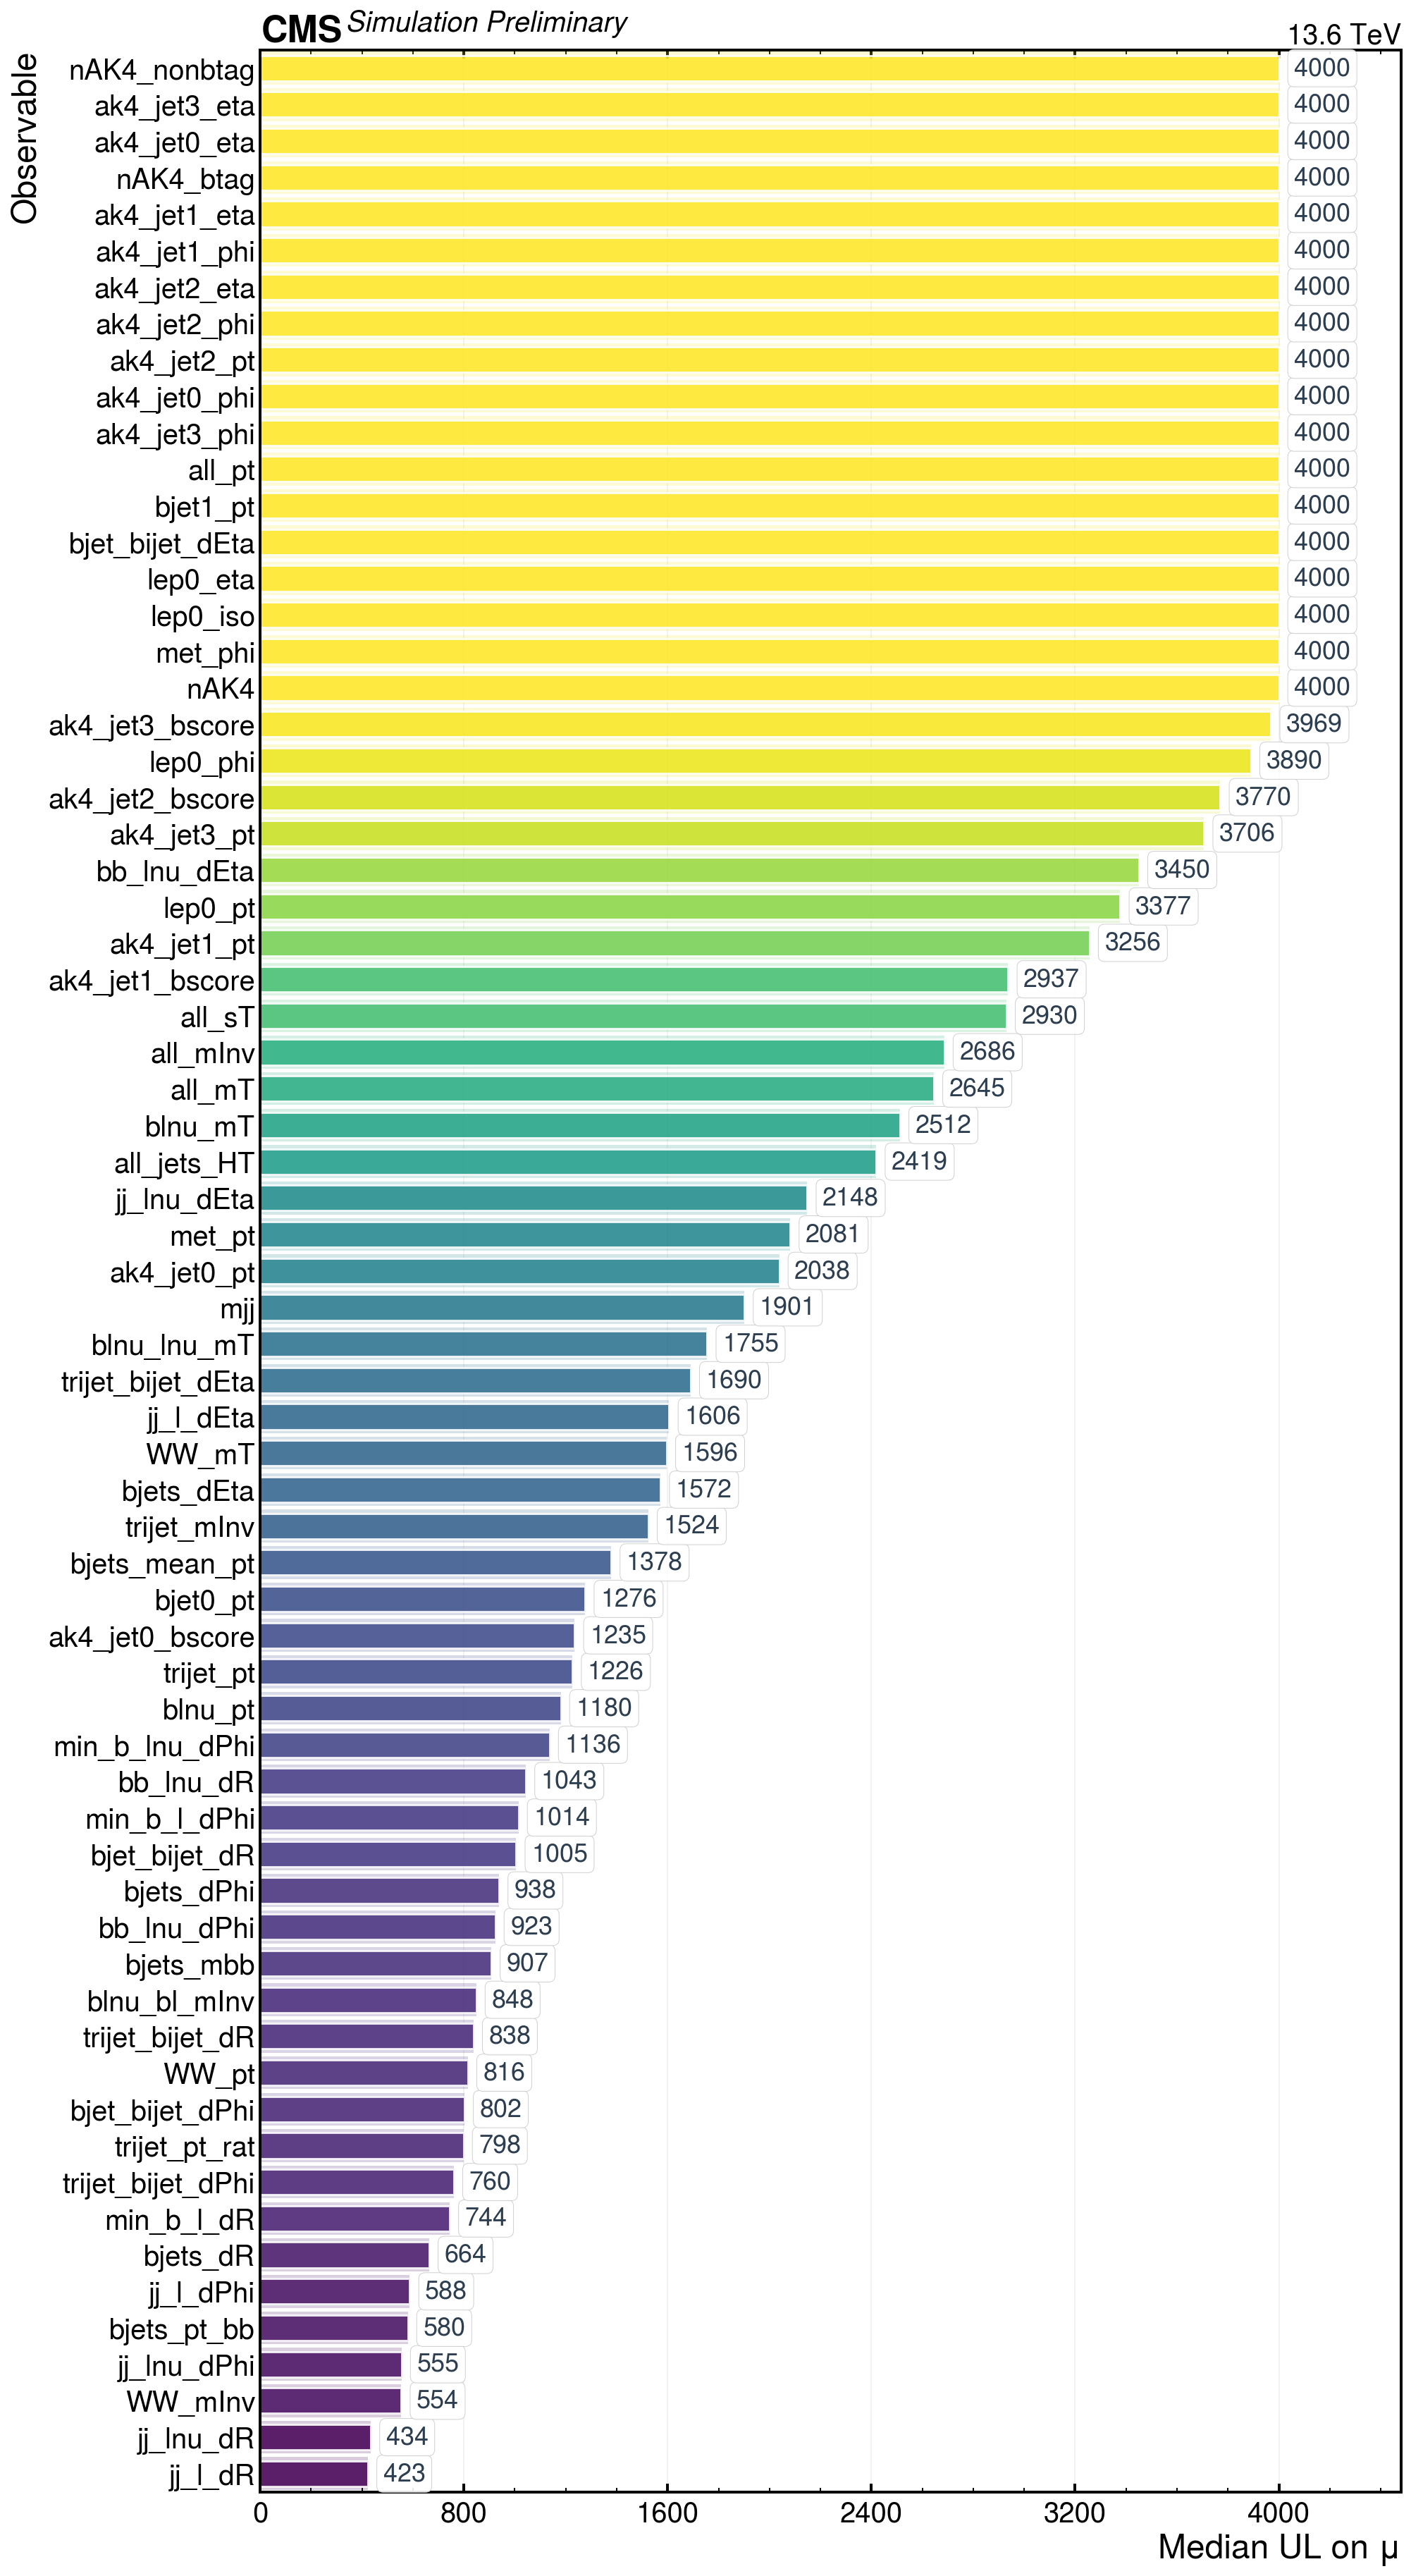

In [21]:
file_path = projectdir / 'JetTop_odd' / 'fits_new' / 'summary_results.txt'
df_vars = ResultsManager.load_summary_files(file_path)
df_vars = df_vars.sort_values('mu', ascending=True).reset_index(drop=True)
df_vars = df_vars.dropna()
outfile = Path('llr_study') / "UL_vars.pdf"
hierarchical_UL_plot(df_vars, outfile=outfile , ylabel='Observable')

In [22]:
file_path = projectdir / 'crtd' / 'LLR_crtd_odd' / 'fits_new' / 'summary_results.txt'
df_llrs_from_vars = ResultsManager.load_summary_files(file_path)

df_llrs_from_1D = df_llrs_from_vars[df_llrs_from_vars['obs_type'] == 'llr_from_1D']
df_llrs_from_2D = df_llrs_from_vars[df_llrs_from_vars['obs_type'] == 'llr_from_2D']
df_llrs_from_3D = df_llrs_from_vars[df_llrs_from_vars['obs_type'] == 'llr_from_3D']

/tmp/anunezde/ipykernel_2402607/517334836.py:86: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_jitter, subset['mu'], c=plasma_colors[i], s=120, alpha=0.3, edgecolors='none', zorder=1)


CMS-style enhanced scatter plot saved to llr_study/llr_factorized_ULs.pdf


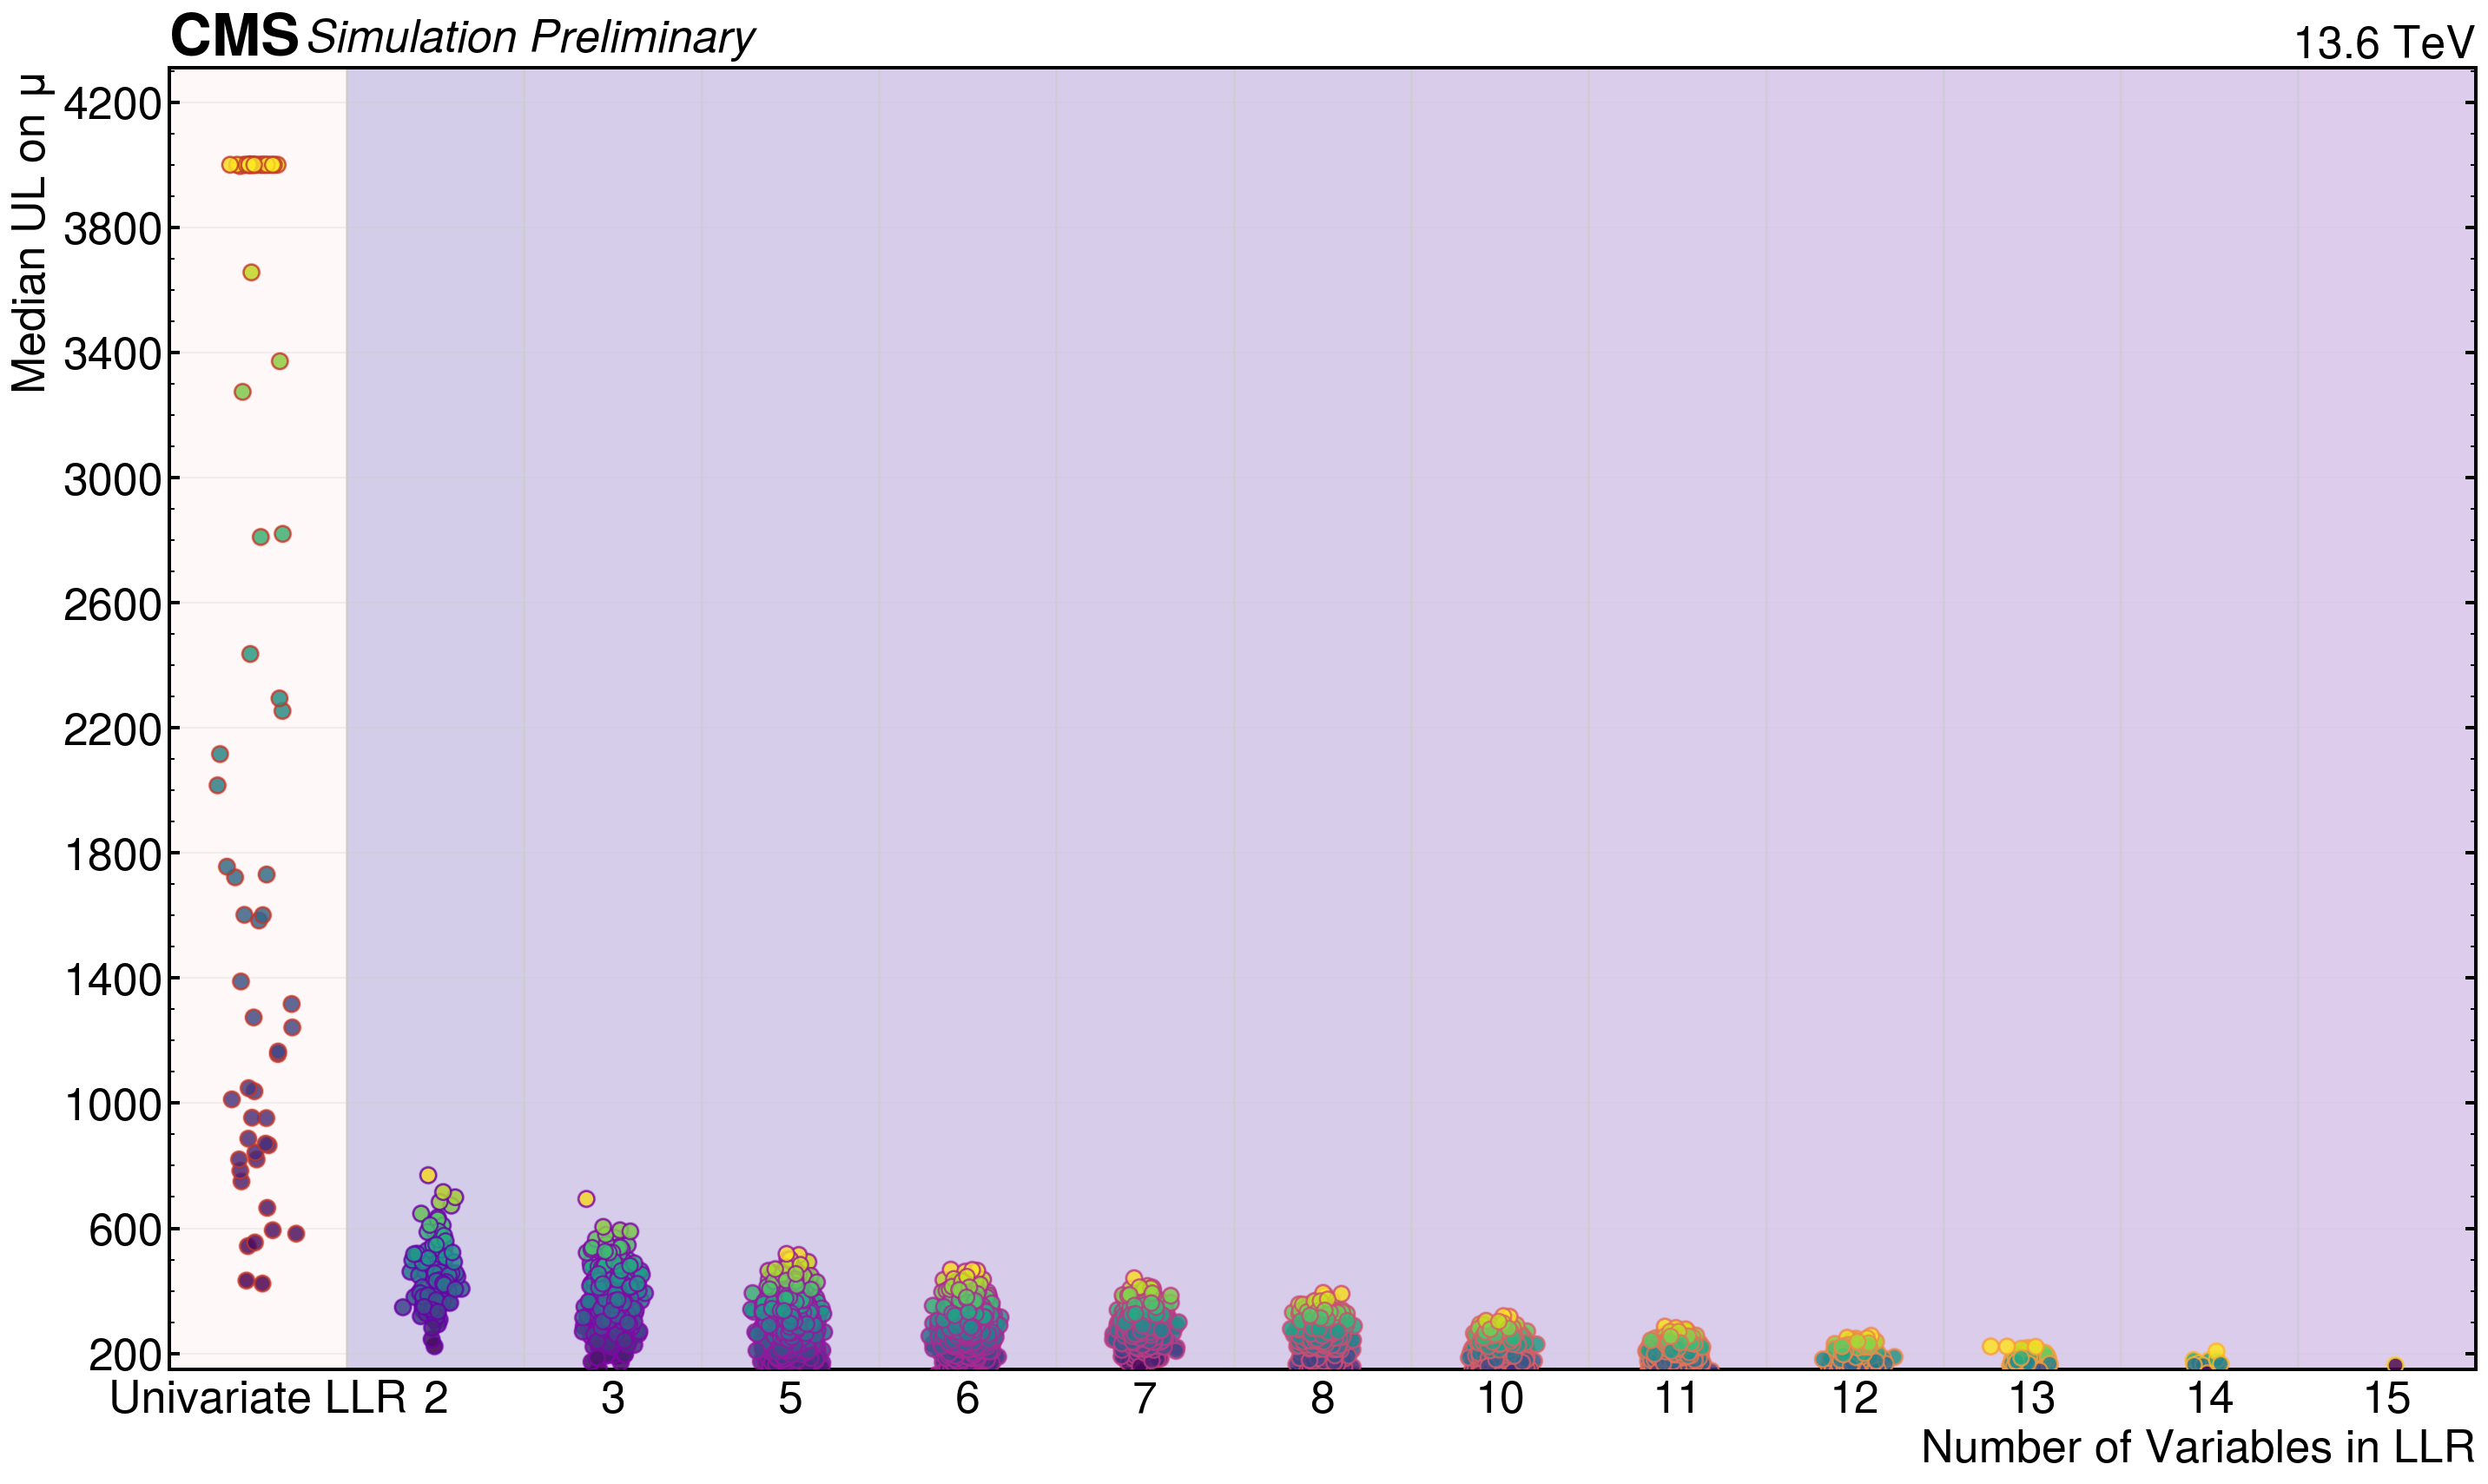

In [23]:
df_multivar = pd.concat([df_llrs_fact, df_llrs_from_1D])
scatterplot_UL_by_type(df_multivar, Path('llr_study') / 'llr_factorized_ULs.pdf')

CMS-style enhanced scatter plot saved to llr_study/llr_from_vars_ULs.pdf


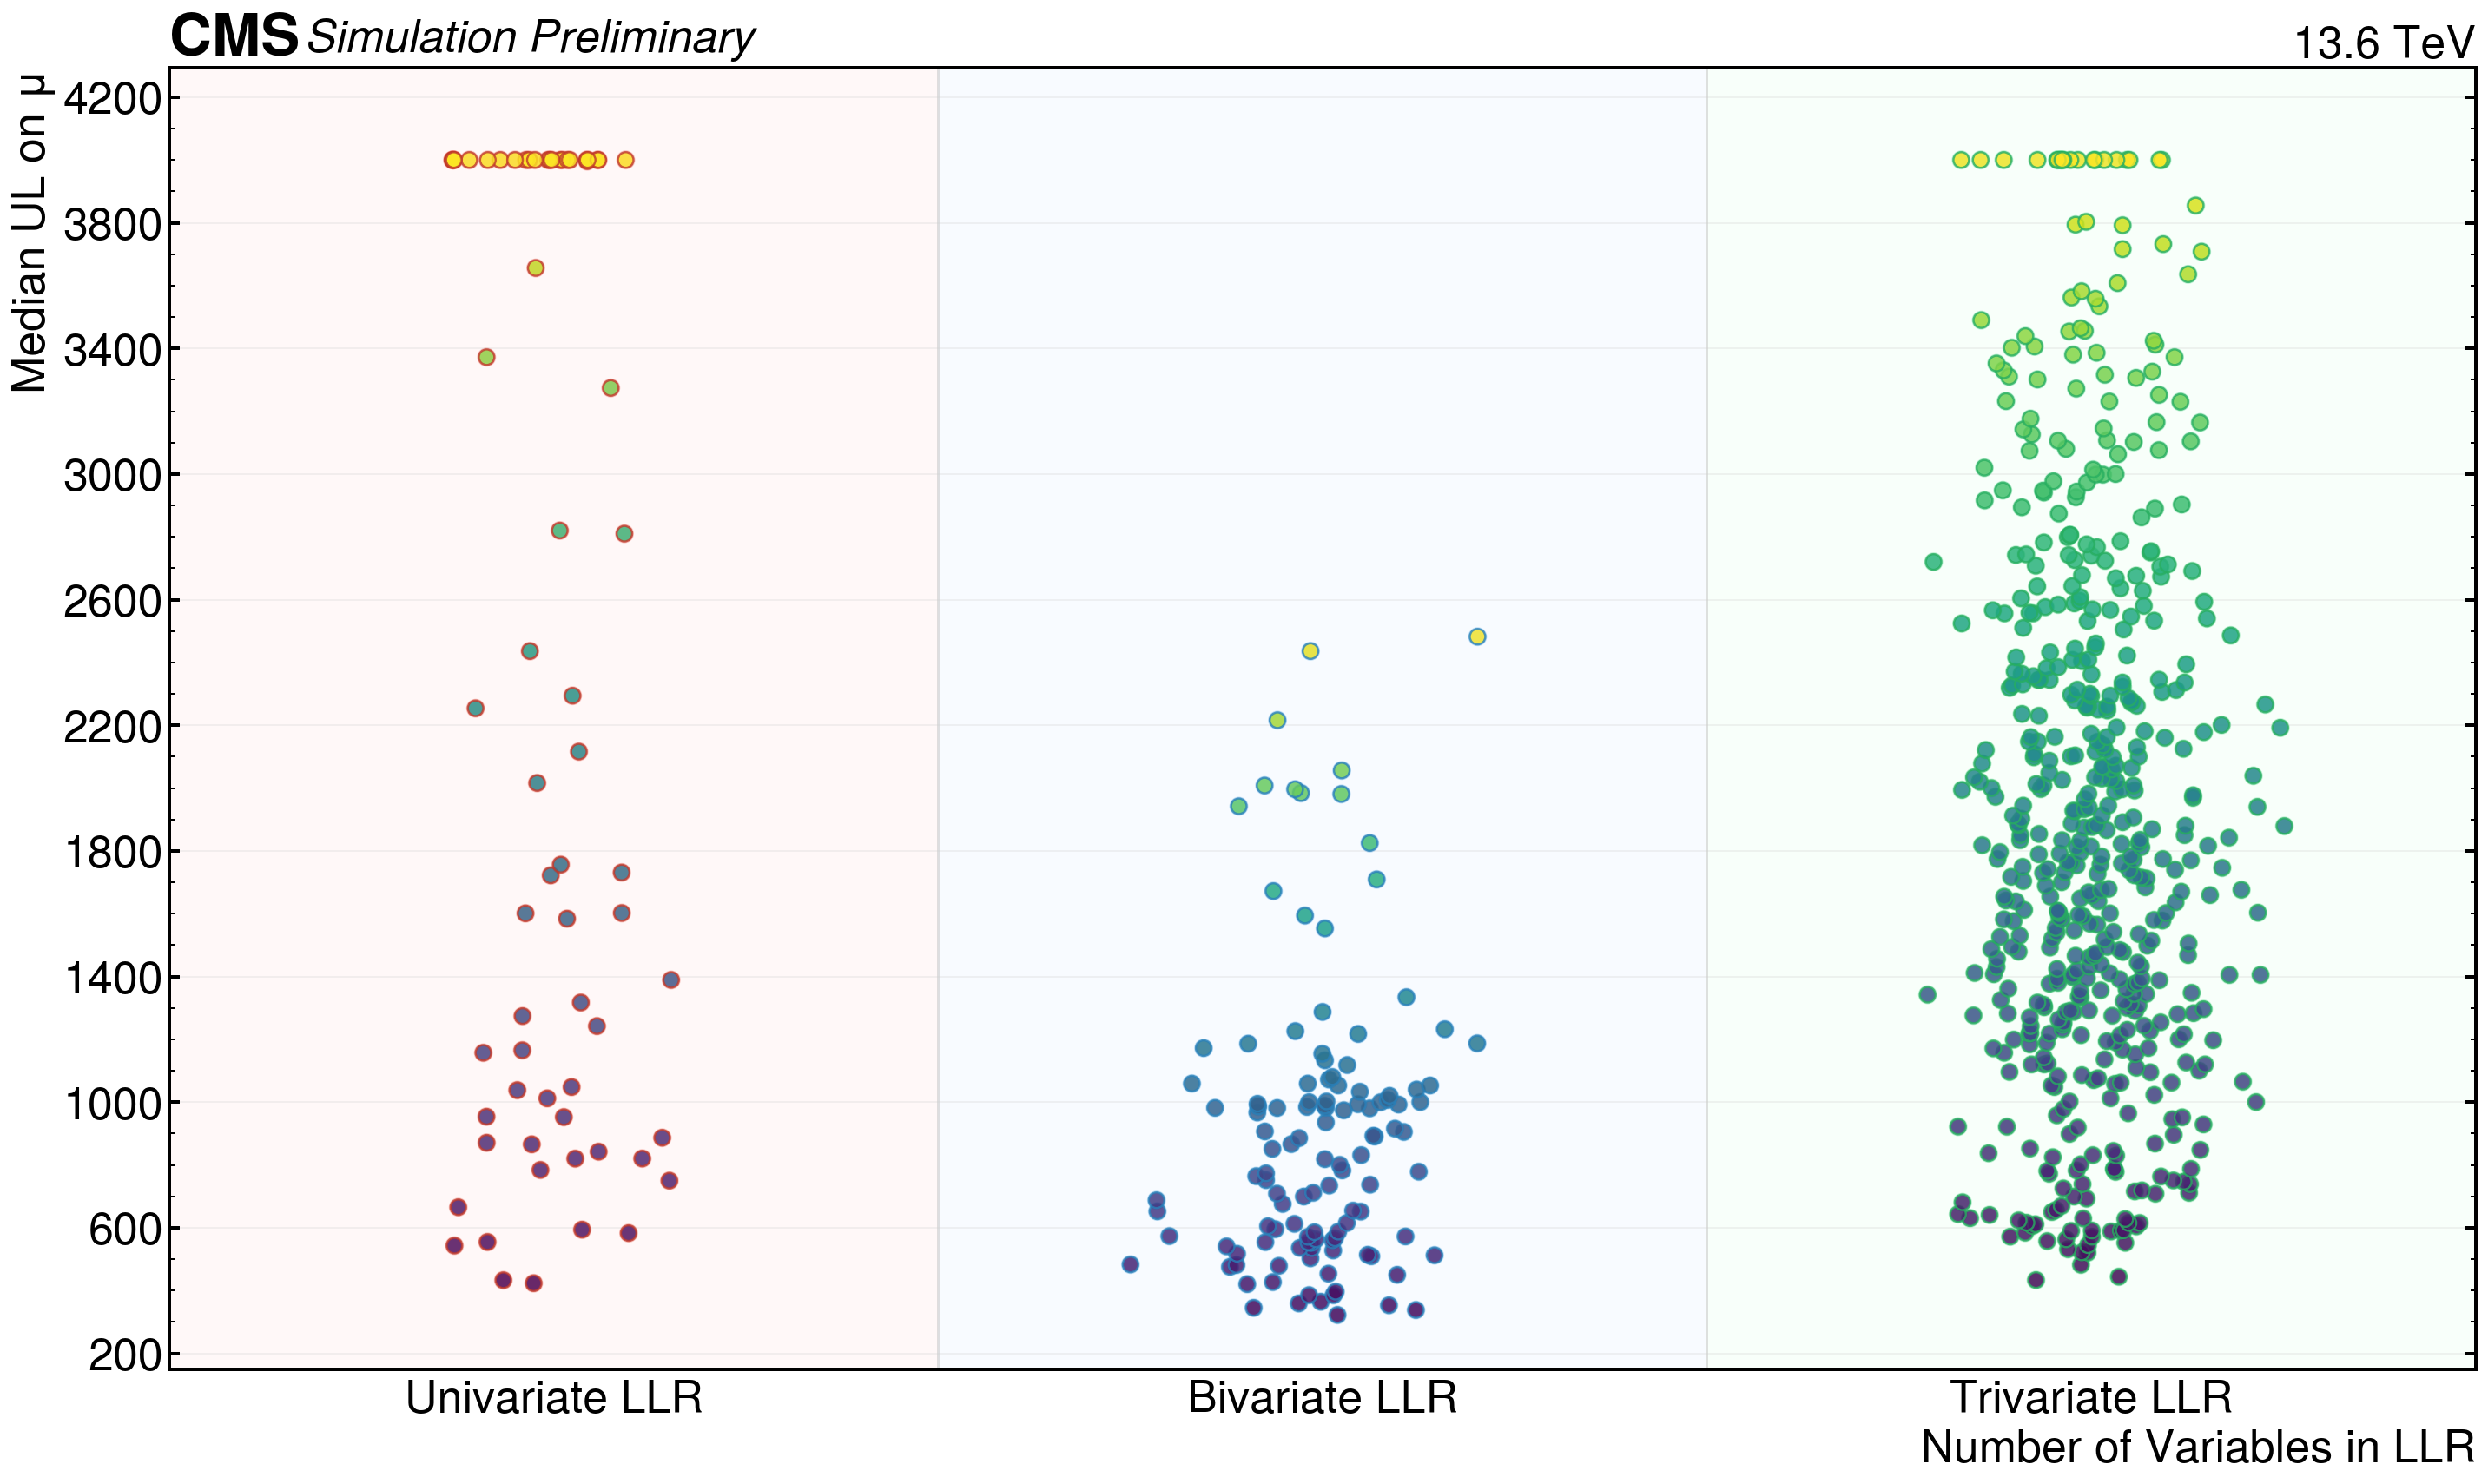

In [24]:
scatterplot_UL_by_type(df_llrs_from_vars, Path('llr_study') / 'llr_from_vars_ULs.pdf')

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


CMS-style hierarchical plot saved to llr_study/all_llrs_from_1D.pdf


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


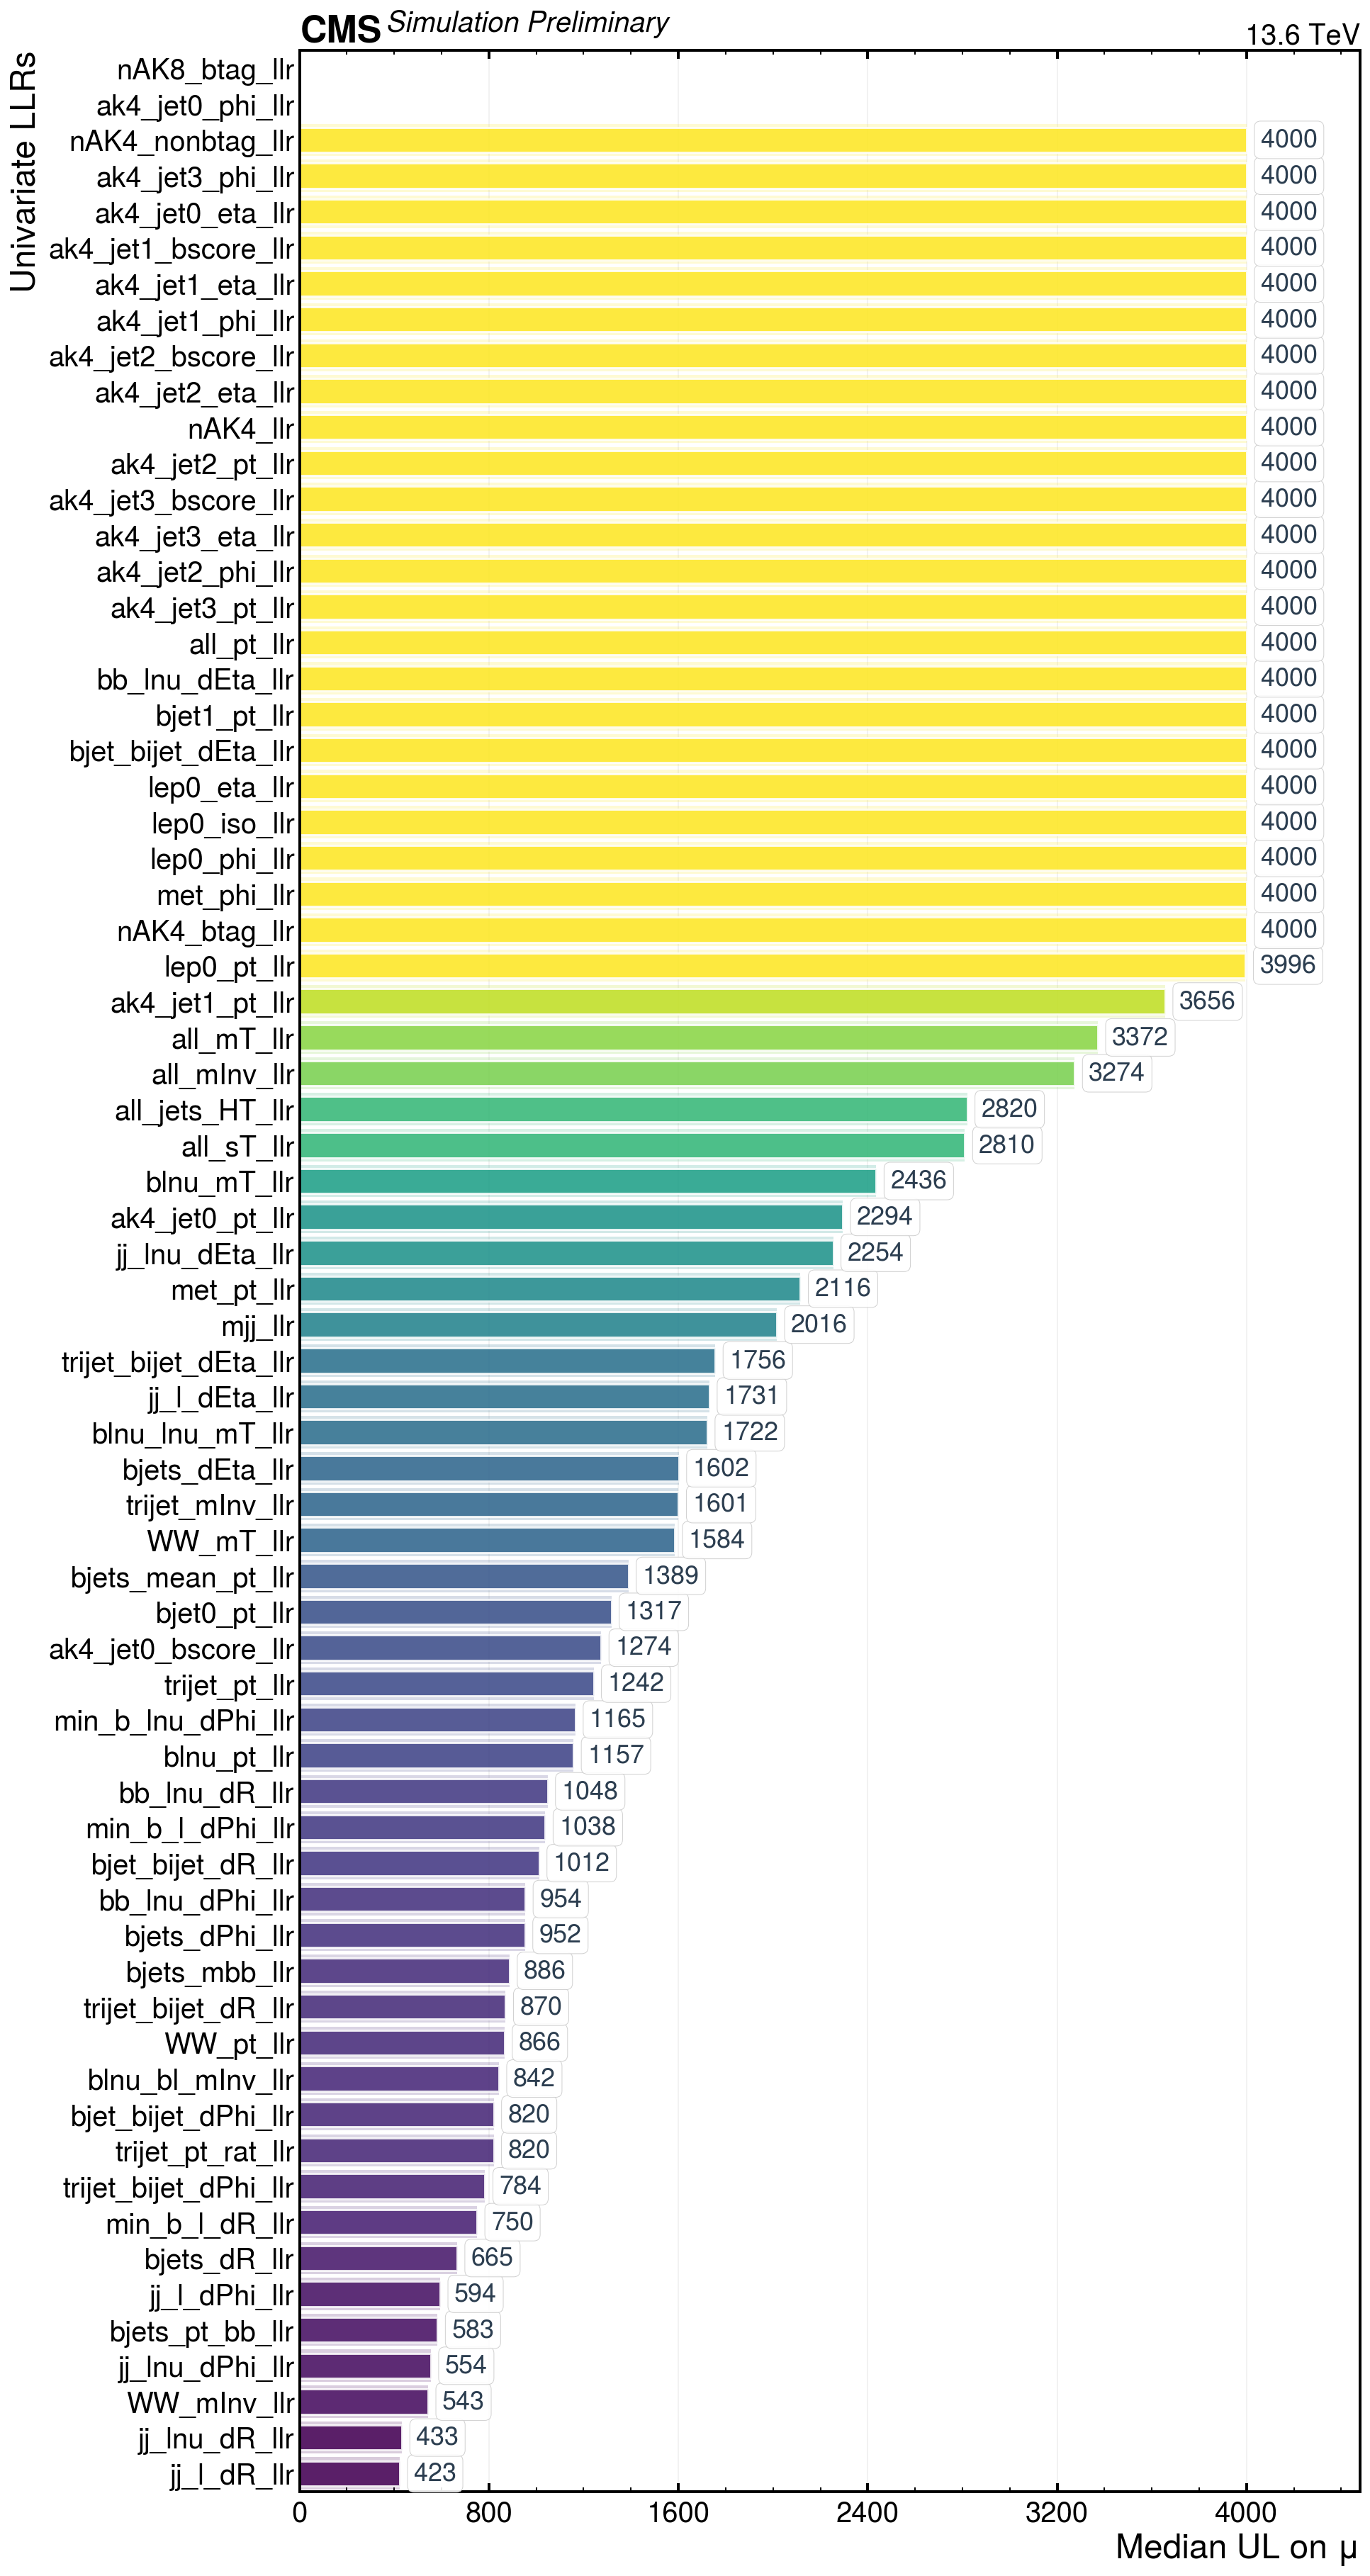

In [ ]:
df_llrs_from_1D = df_llrs_from_1D.sort_values('mu', ascending=True).reset_index(drop=True)
outfile = Path('llr_study') / "all_llrs_from_1D.pdf"
hierarchical_UL_plot(df_llrs_from_1D, outfile=outfile , ylabel='Univariate LLRs')

CMS-style hierarchical plot saved to llr_study/top10_llrs_from_2D.pdf


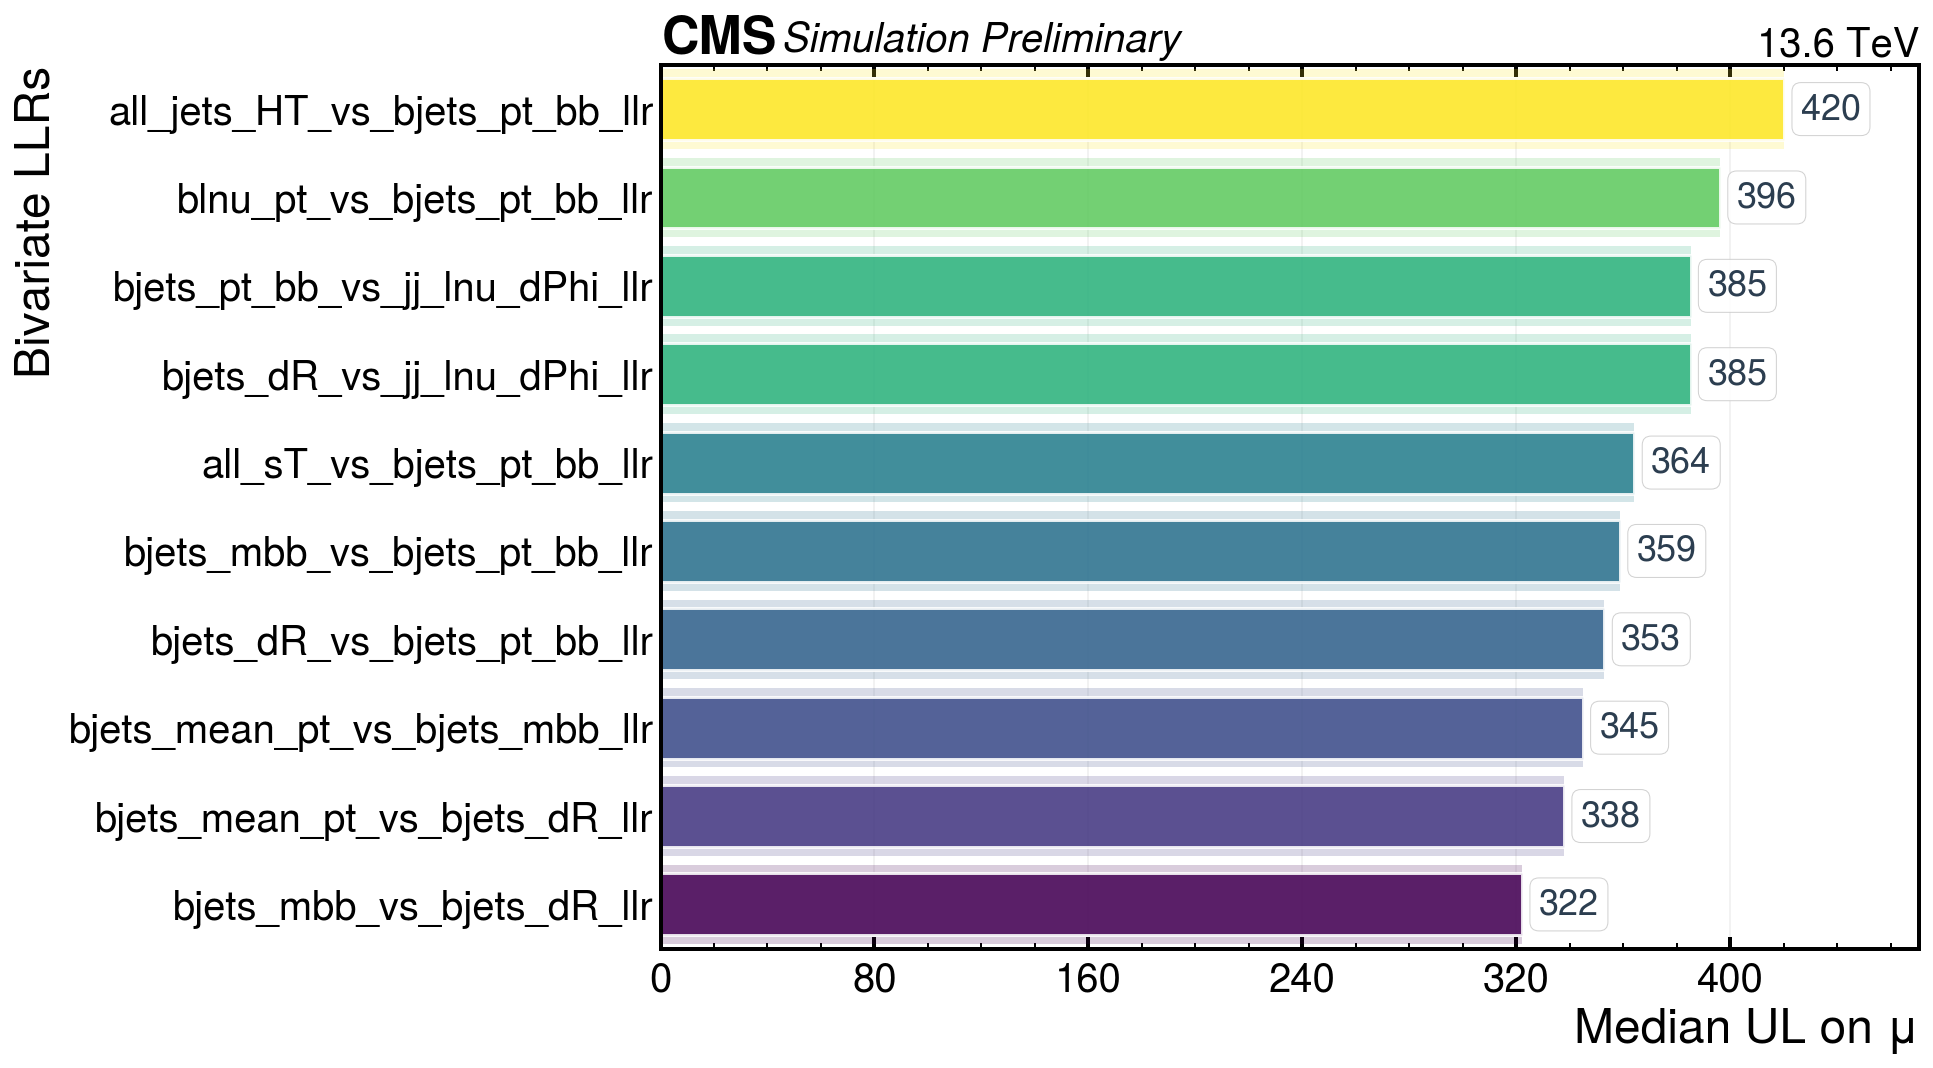

In [ ]:
df_llrs_from_2D = df_llrs_from_2D.sort_values('mu', ascending=True).reset_index(drop=True)
df_llrs_from_2D_top10 = df_llrs_from_2D.head(10)
outfile = Path('llr_study') / "top10_llrs_from_2D.pdf"
hierarchical_UL_plot(df_llrs_from_2D_top10, outfile=outfile , ylabel='Bivariate LLRs')

CMS-style hierarchical plot saved to llr_study/top10_llrs_from_3D.pdf


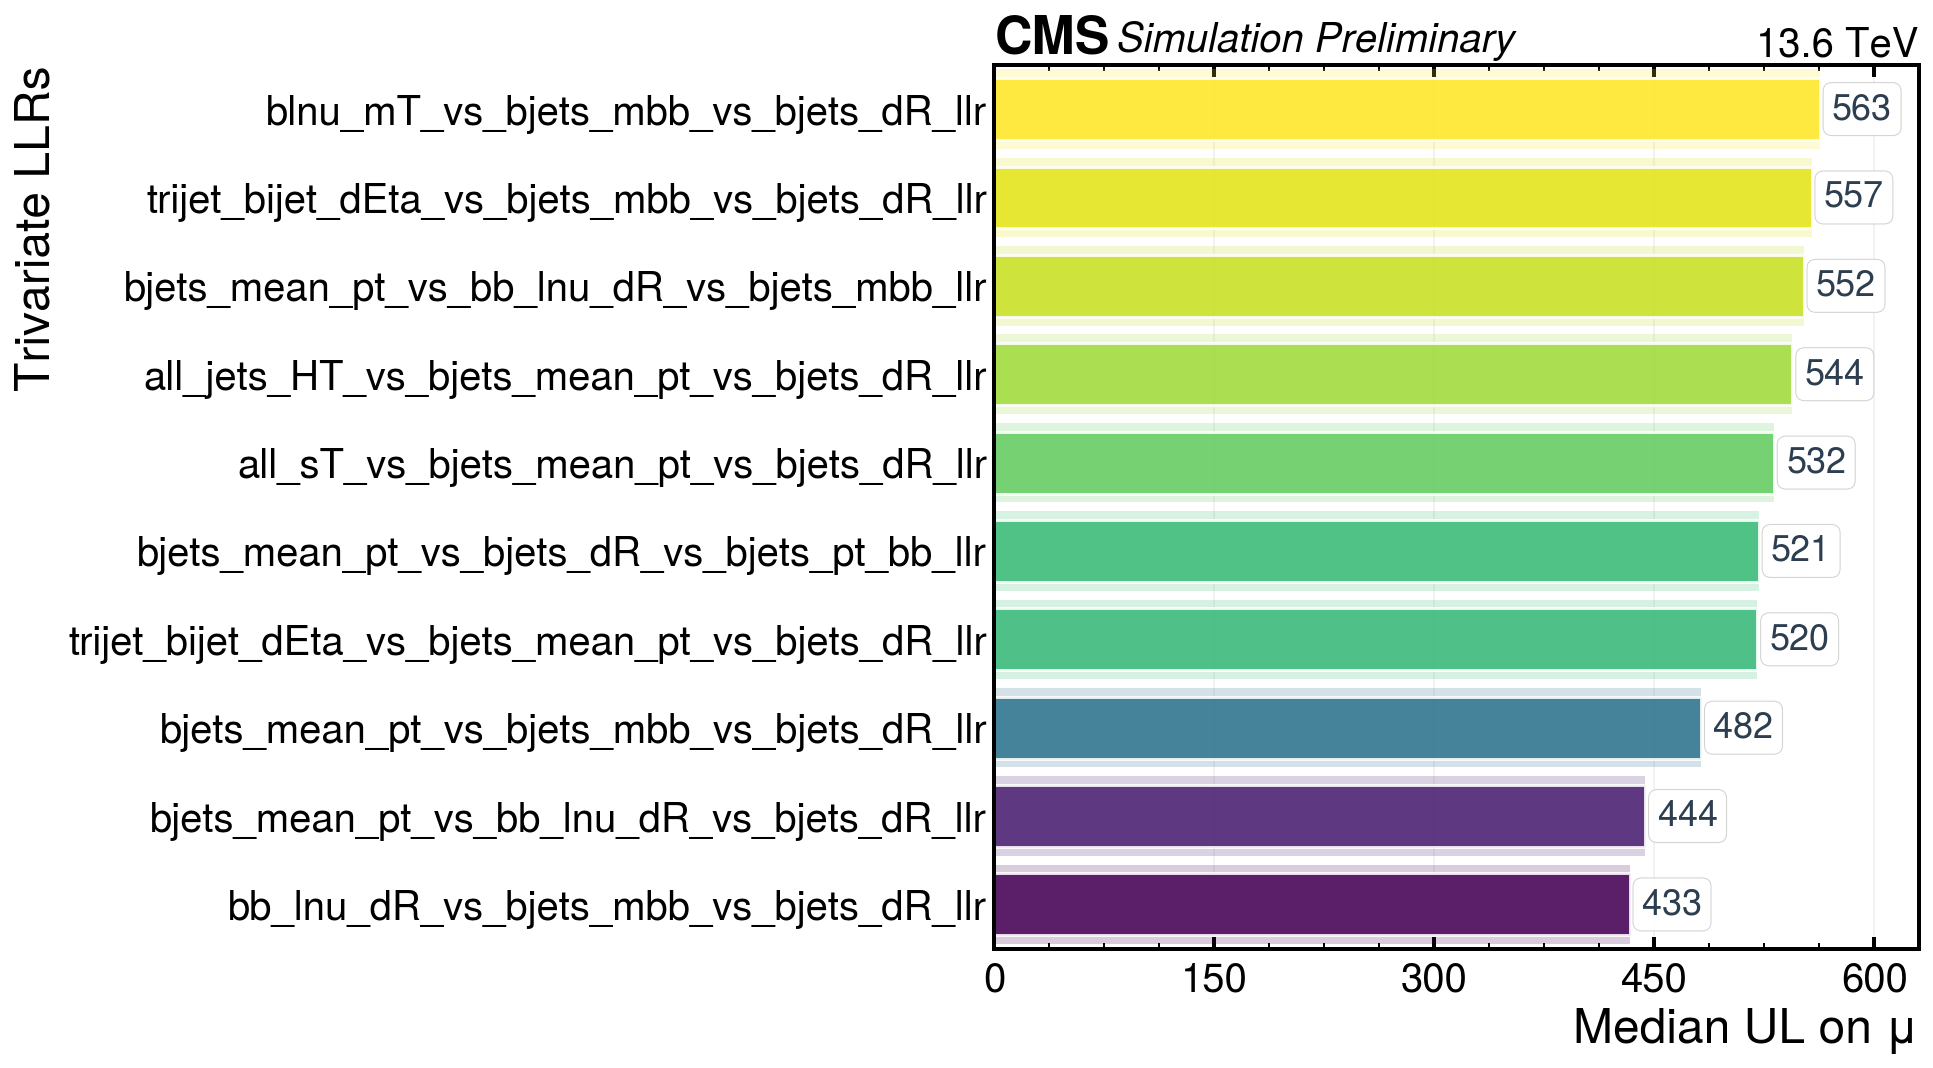

In [ ]:
df_llrs_from_3D = df_llrs_from_3D.sort_values('mu', ascending=True).reset_index(drop=True)
df_llrs_from_3D_top10 = df_llrs_from_3D.head(10)
outfile = Path('llr_study') / "top10_llrs_from_3D.pdf"
hierarchical_UL_plot(df_llrs_from_3D_top10, outfile=outfile , ylabel='Trivariate LLRs')

Saved to llr_study/trend_factorized_llrs.pdf


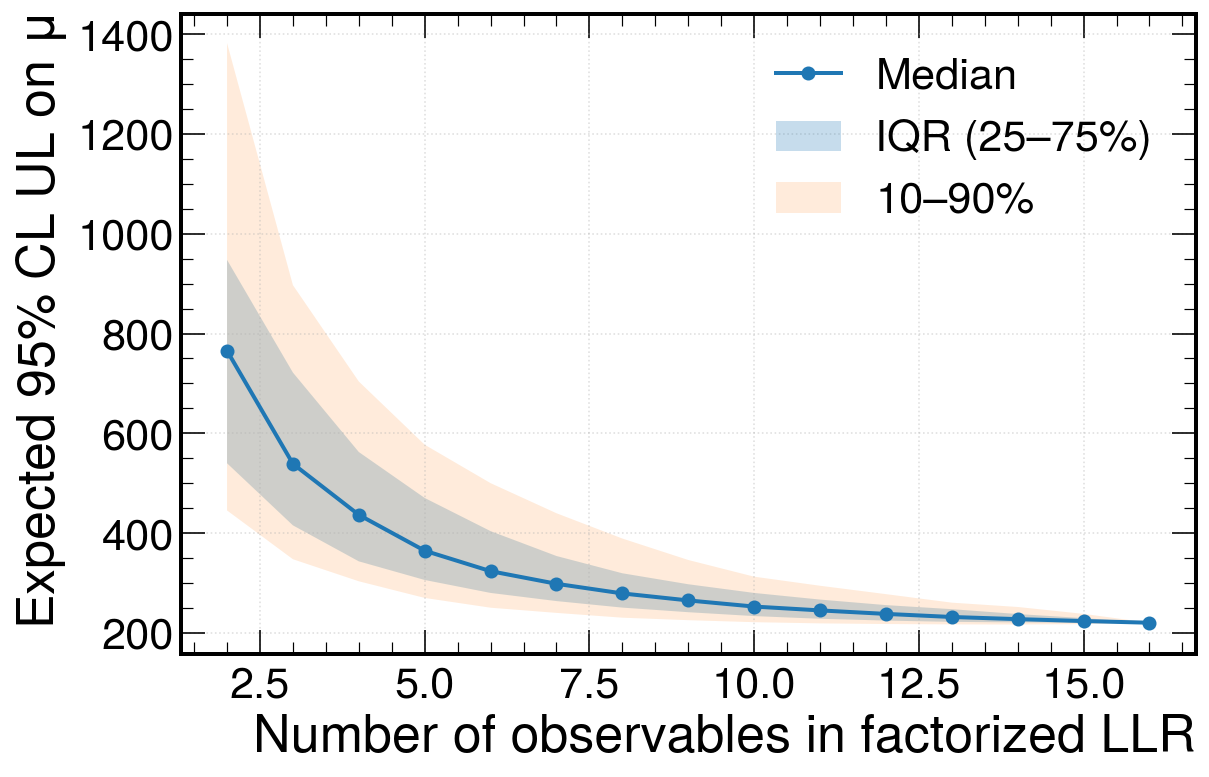

In [20]:
plot_llr_factorized_trend(df_llrs_fact, outfile = Path('llr_study') / "trend_factorized_llrs.pdf")

/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/matplotlib/lines.py:1205: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  neq = current != val


CMS-style enhanced boxplot saved to llr_study/llr_factorized_ULs_boxplot.pdf


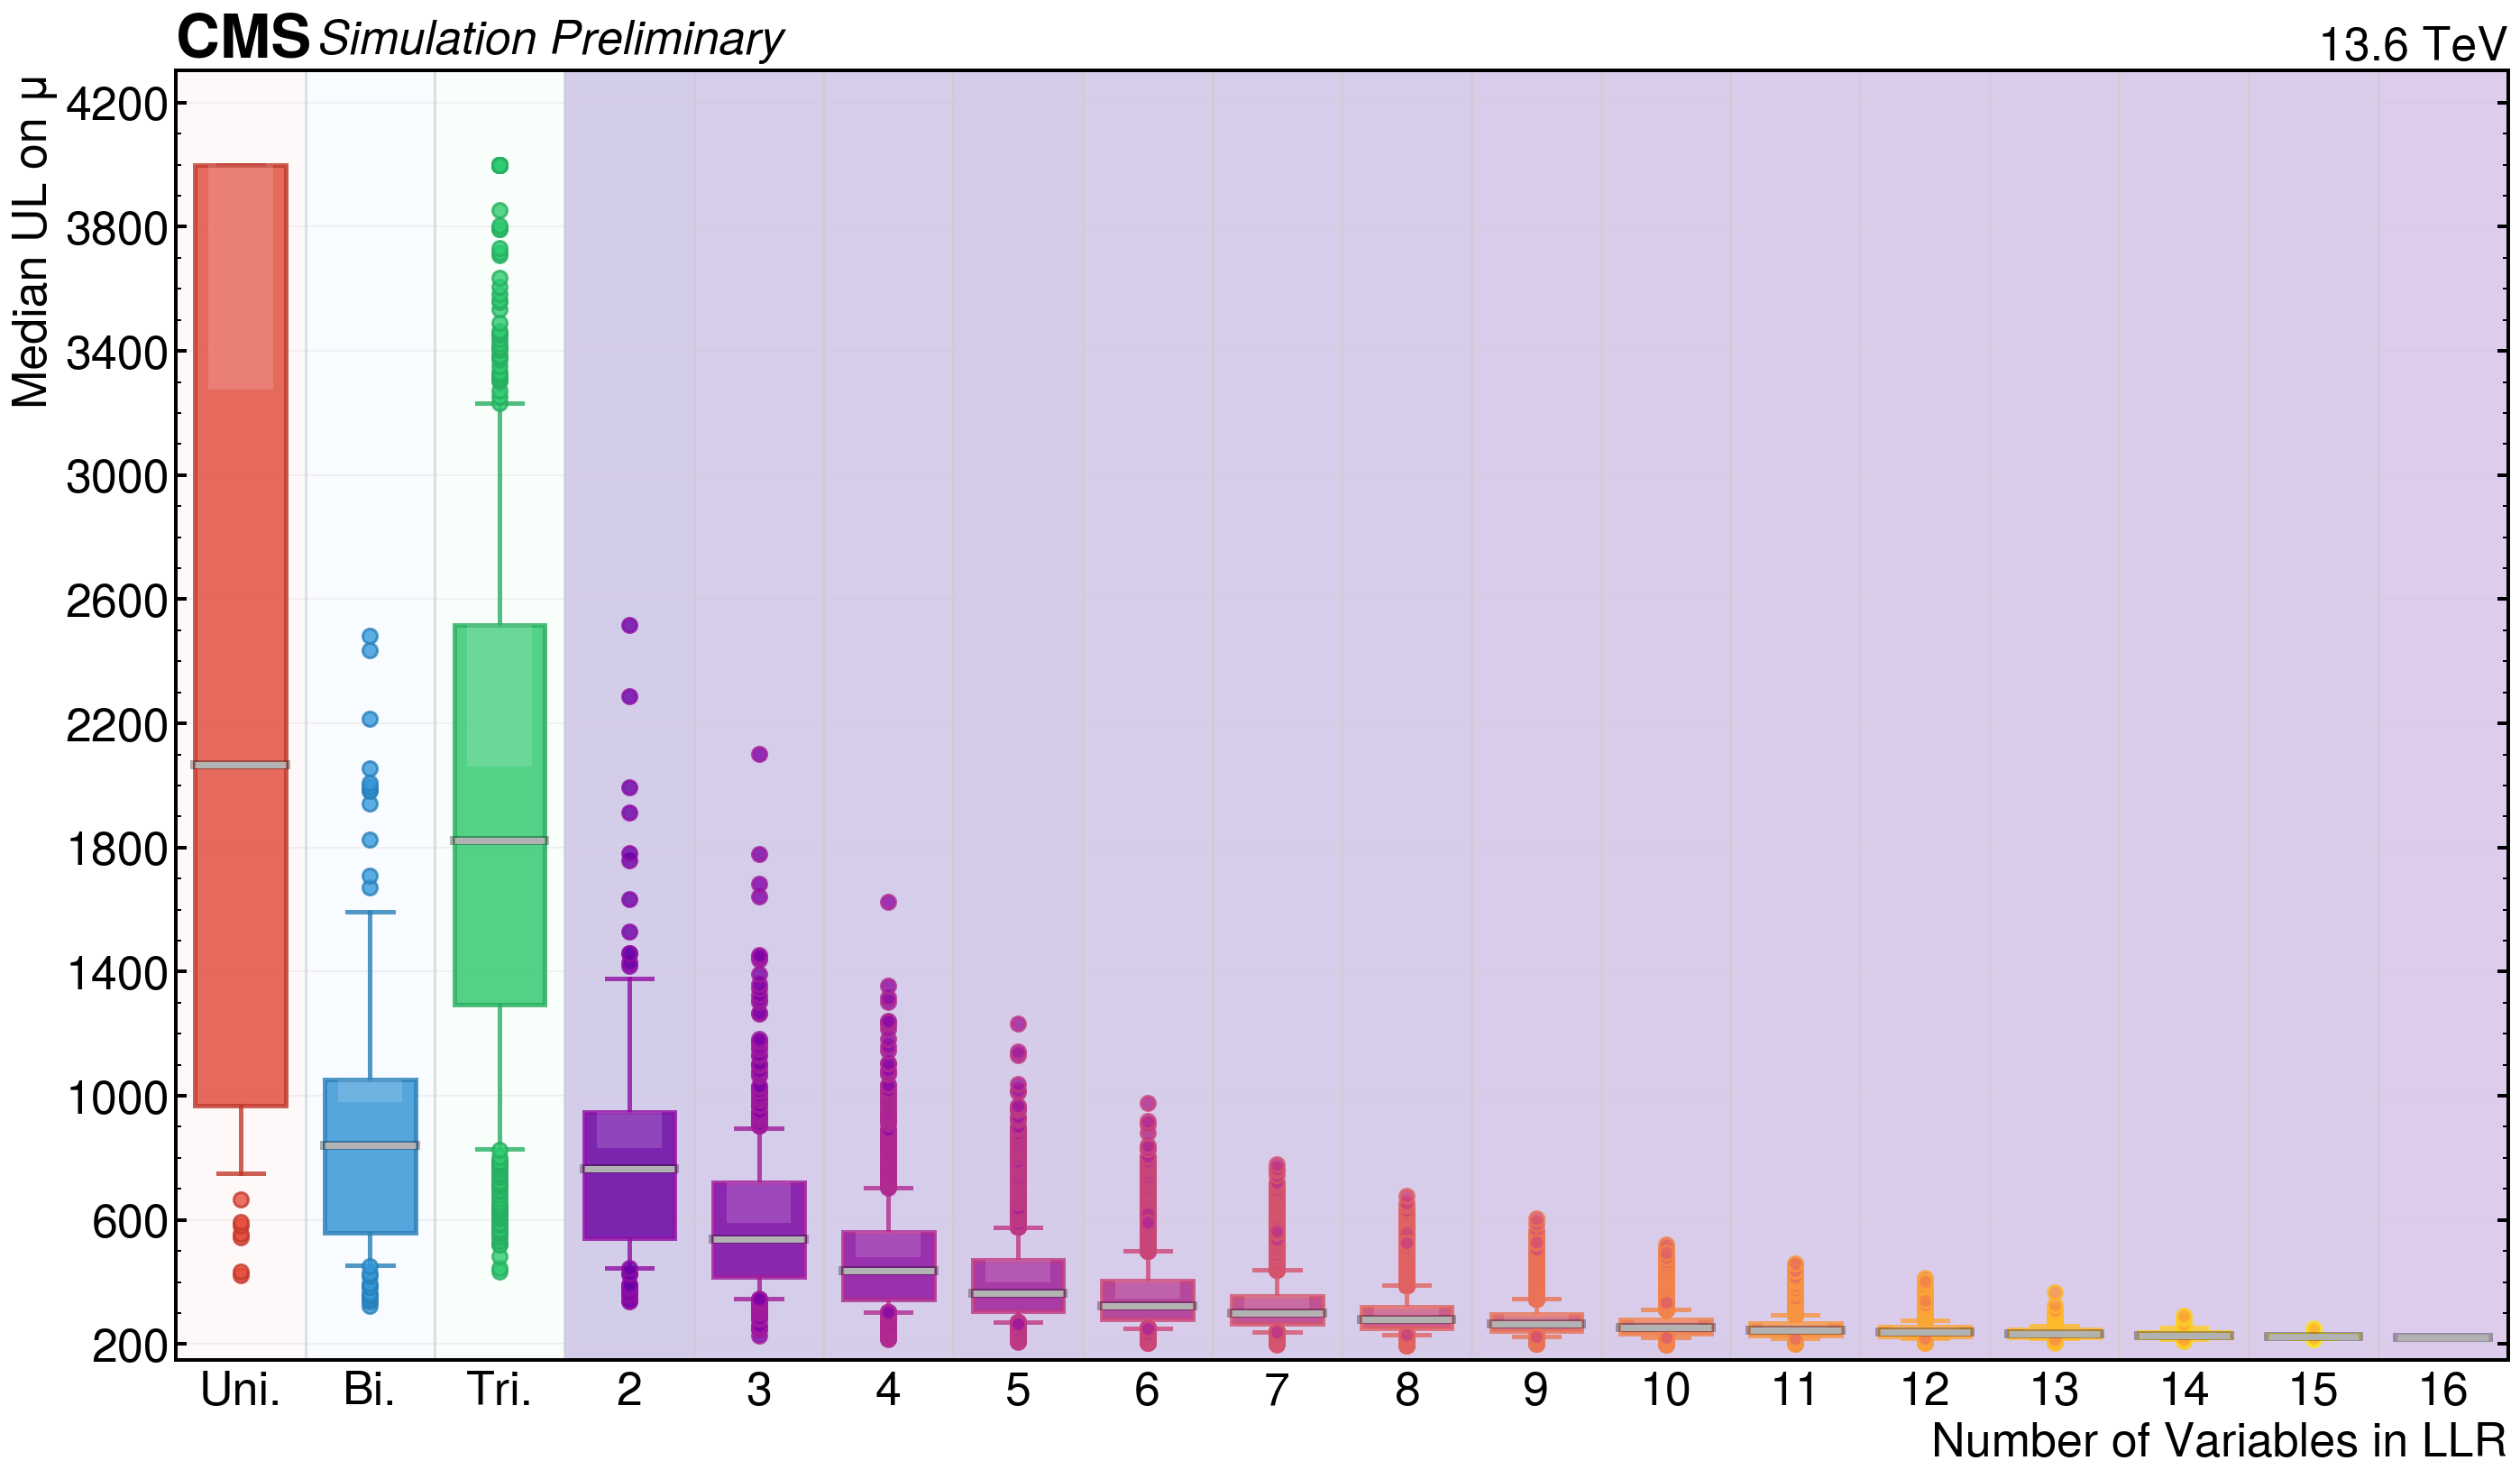

In [ ]:
df_full = pd.concat([df_llrs_fact, df_llrs_from_vars])
boxplot_UL_by_type(df_full, Path('llr_study') / 'llr_factorized_ULs_boxplot.pdf')